# **Logistic Regression with EDA and PCA**

# Import the neccessary libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

In [4]:
df=pd.read_csv(r'D:\fsds\projects\datasets\logistic regression with eda and pcs\adult.csv')

# EDA

## Checking the shape if the dataset

In [5]:
df.shape

(32561, 15)

## Previewing the dataset

In [6]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Viweing dataframe summary

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## Encode `?` as `NaNs`

In [8]:
df[df=='?'] = np.nan

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## Checking for missing values

In [10]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

## Impute missing values

In [11]:
for col in ['workclass', 'occupation', 'native.country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [12]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

## Setting feature vector and target variable

In [13]:
X=df.drop(['income'], axis=1)
y = df['income']

In [14]:
X.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States


# Splitting data into train and test data

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

# Feature Engineering

## Encoding categotrical data 

In [16]:
from sklearn import preprocessing

categorical = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
for feature in categorical:
    le=preprocessing.LabelEncoder()
    X_train[feature]=le.fit_transform(X_train[feature])
    X_test[feature]=le.transform(X_test[feature])

# Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
X_train=pd.DataFrame(sc.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(sc.transform(X_test), columns=X.columns)

X_train.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,0.101484,2.600478,-1.494279,-0.332263,1.133894,-0.402341,-0.782234,2.214196,0.39298,-1.430470,-0.145189,-0.217407,-1.662414,0.262317
1,0.028248,-1.884720,0.438778,0.184396,-0.423425,-0.402341,-0.026696,-0.899410,0.39298,0.699071,-0.145189,-0.217407,-0.200753,0.262317
2,0.247956,-0.090641,0.045292,1.217715,-0.034095,0.926666,-0.782234,-0.276689,0.39298,-1.430470,-0.145189,-0.217407,-0.038346,0.262317
3,-0.850587,-1.884720,0.793152,0.184396,-0.423425,0.926666,-0.530388,0.968753,0.39298,0.699071,-0.145189,-0.217407,-0.038346,0.262317
4,-0.044989,-2.781760,-0.853275,0.442726,1.523223,-0.402341,-0.782234,-0.899410,0.39298,0.699071,-0.145189,-0.217407,-0.038346,0.262317


## Logistic Regression model with all features

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

reg = LogisticRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print('Accuracy of Logistic Regression model with all features:{0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Accuracy of Logistic Regression model with all features:0.8218


# Logistic Regression with PCA

In [23]:
from sklearn.decomposition import PCA
pca=PCA()
X_train=pca.fit_transform(X_train)
pca.explained_variance_ratio_

array([0.14757168, 0.10182915, 0.08147199, 0.07880174, 0.07463545,
       0.07274281, 0.07009602, 0.06750902, 0.0647268 , 0.06131155,
       0.06084207, 0.04839584, 0.04265038, 0.02741548])

### Logistic regression with first 13 feature

In [26]:
X = df.drop(['income','native.country'], axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

categorical = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex']
for feature in categorical:
    le=preprocessing.LabelEncoder()
    X_train[feature]=le.fit_transform(X_train[feature])
    X_test[feature]=le.transform(X_test[feature])
    
X_train=pd.DataFrame(sc.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(sc.transform(X_test), columns=X.columns)

reg = LogisticRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print('Accuracy of Logistic Regression model with all features:{0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Accuracy of Logistic Regression model with all features:0.8213


### Logistic Regression with 12 features

In [27]:
X = df.drop(['income','native.country', 'hours.per.week'], axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

categorical = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex']
for feature in categorical:
    le=preprocessing.LabelEncoder()
    X_train[feature]=le.fit_transform(X_train[feature])
    X_test[feature]=le.transform(X_test[feature])
    
X_train=pd.DataFrame(sc.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(sc.transform(X_test), columns=X.columns)

reg = LogisticRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print('Accuracy of Logistic Regression model with all features:{0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Accuracy of Logistic Regression model with all features:0.8227


### Comments
- the accuracy has increased to 82.27% when 2 features were dropped.

- lets drop one more feature and see if the accuracy will increase or not 

In [28]:
X = df.drop(['income','native.country', 'hours.per.week', 'capital.loss'], axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

categorical = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex']
for feature in categorical:
    le=preprocessing.LabelEncoder()
    X_train[feature]=le.fit_transform(X_train[feature])
    X_test[feature]=le.transform(X_test[feature])
    
X_train=pd.DataFrame(sc.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(sc.transform(X_test), columns=X.columns)

reg = LogisticRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print('Accuracy of Logistic Regression model with all features:{0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Accuracy of Logistic Regression model with all features:0.8186


### Comments

- we can see that accuracy has dropped to 81.86% if 3 features were dropped.

- so the maximum accuracy we got was 82.27% when we dropped 2 features. 

## Selecting number of dimensions

- the above process is suggested if the number of dimensions are small. 

- if we have very large number of dimensions, the suggested approach is to compute all the dimensions that can explain large portion of the variance,

- below code computes PCA without dimensionality reduction, then computes the minimum number of dimensions required to preserver 90% of the training variance

In [29]:
X=df.drop(['income'], axis=1)
y=df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

categorical = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
for feature in categorical:
    le=preprocessing.LabelEncoder()
    X_train[feature]=le.fit_transform(X_train[feature])
    X_test[feature]=le.transform(X_test[feature])
    
X_train=pd.DataFrame(sc.fit_transform(X_train), columns=X.columns)

pca=PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
dim= np.argmax(cumsum >= 0.90) + 1
print('Number of dimensions required to preserve 90% of the variance: ', dim)

Number of dimensions required to preserve 90% of the variance:  12


## Plotting exlpained variance ratio with number of dimensions

TypeError: _AxesBase.set_xlim() takes from 1 to 3 positional arguments but 4 were given

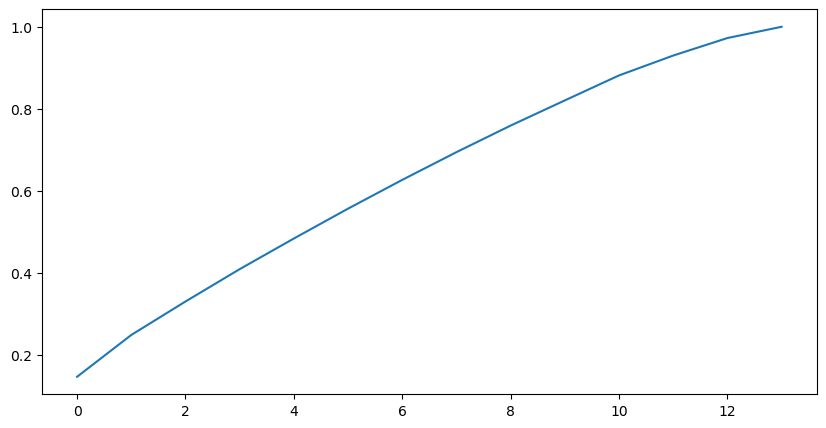

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlim(0, 15,1)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.legend(['Explained Variance'])
plt.show()

### Comments

The plot confirms that almost 90% of variance is explained by first 12 features